# Lab 3 — Support Vector Machines
Part 1 knn from scratch
in Lab2 and Lab3 we implemented linear and logistic regression and svm using gradient descent : so with optimization and leaning parameters and find the decision boundary 
in this lab we will see a new philosophie ,   building a  lazy resuable machine learning estimator 
We will implment k-nearest neighbors  from scratch 
.......
# setup 
We'll work with BankNote_Authentication dataset the task is to  predict the quuality ....
First the standard imports__numpy/pandas for datahandling, matplotlib for  ploting, and a few sklearn utilities we'll resue StandardScaler, train_test_split,accuarcy score ,and KNeigh  ...


In [56]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report,accuracy_score,ConfusionMatrixDisplay
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler


In [57]:
df = pd.read_csv("BankNote_Authentication.csv")

In [58]:
shape = df.shape
print(f"The dataset shape:{shape}\n")
print(f"n_features: {shape[1]-1} , n_samples: {shape[0]}\n")
print(f"data set first 5 samples:{df.head()}")
print(f"print the data set info :\n{df.info()}\n")
print(f"print data set description:{df.describe()}")

The dataset shape:(1372, 5)

n_features: 4 , n_samples: 1372

data set first 5 samples:   variance  skewness  curtosis  entropy  class
0   3.62160    8.6661   -2.8073 -0.44699      0
1   4.54590    8.1674   -2.4586 -1.46210      0
2   3.86600   -2.6383    1.9242  0.10645      0
3   3.45660    9.5228   -4.0112 -3.59440      0
4   0.32924   -4.4552    4.5718 -0.98880      0
<class 'pandas.DataFrame'>
RangeIndex: 1372 entries, 0 to 1371
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   variance  1372 non-null   float64
 1   skewness  1372 non-null   float64
 2   curtosis  1372 non-null   float64
 3   entropy   1372 non-null   float64
 4   class     1372 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 53.7 KB
print the data set info :
None

print data set description:          variance     skewness     curtosis      entropy        class
count  1372.000000  1372.000000  1372.000000  1372.000000  1372.000000
mean 

In [59]:
X = df.drop(columns="class").to_numpy()
y = df["class"].to_numpy()
print(type(X))
print(type(y))

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


In [60]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
print(f"training shape:{X_train.shape}")
print(f"Test training shape: {X_test.shape}")

training shape:(1097, 4)
Test training shape: (275, 4)


# Data plot 
before choosing any model  we should see how the data is distributed, and in here we have 4 feature so 4D space and since
we cannot plot so we will plot the 6 different 2D combination and the 
4 3D combination  so u can take an overview and the knn intuition becommes clearer

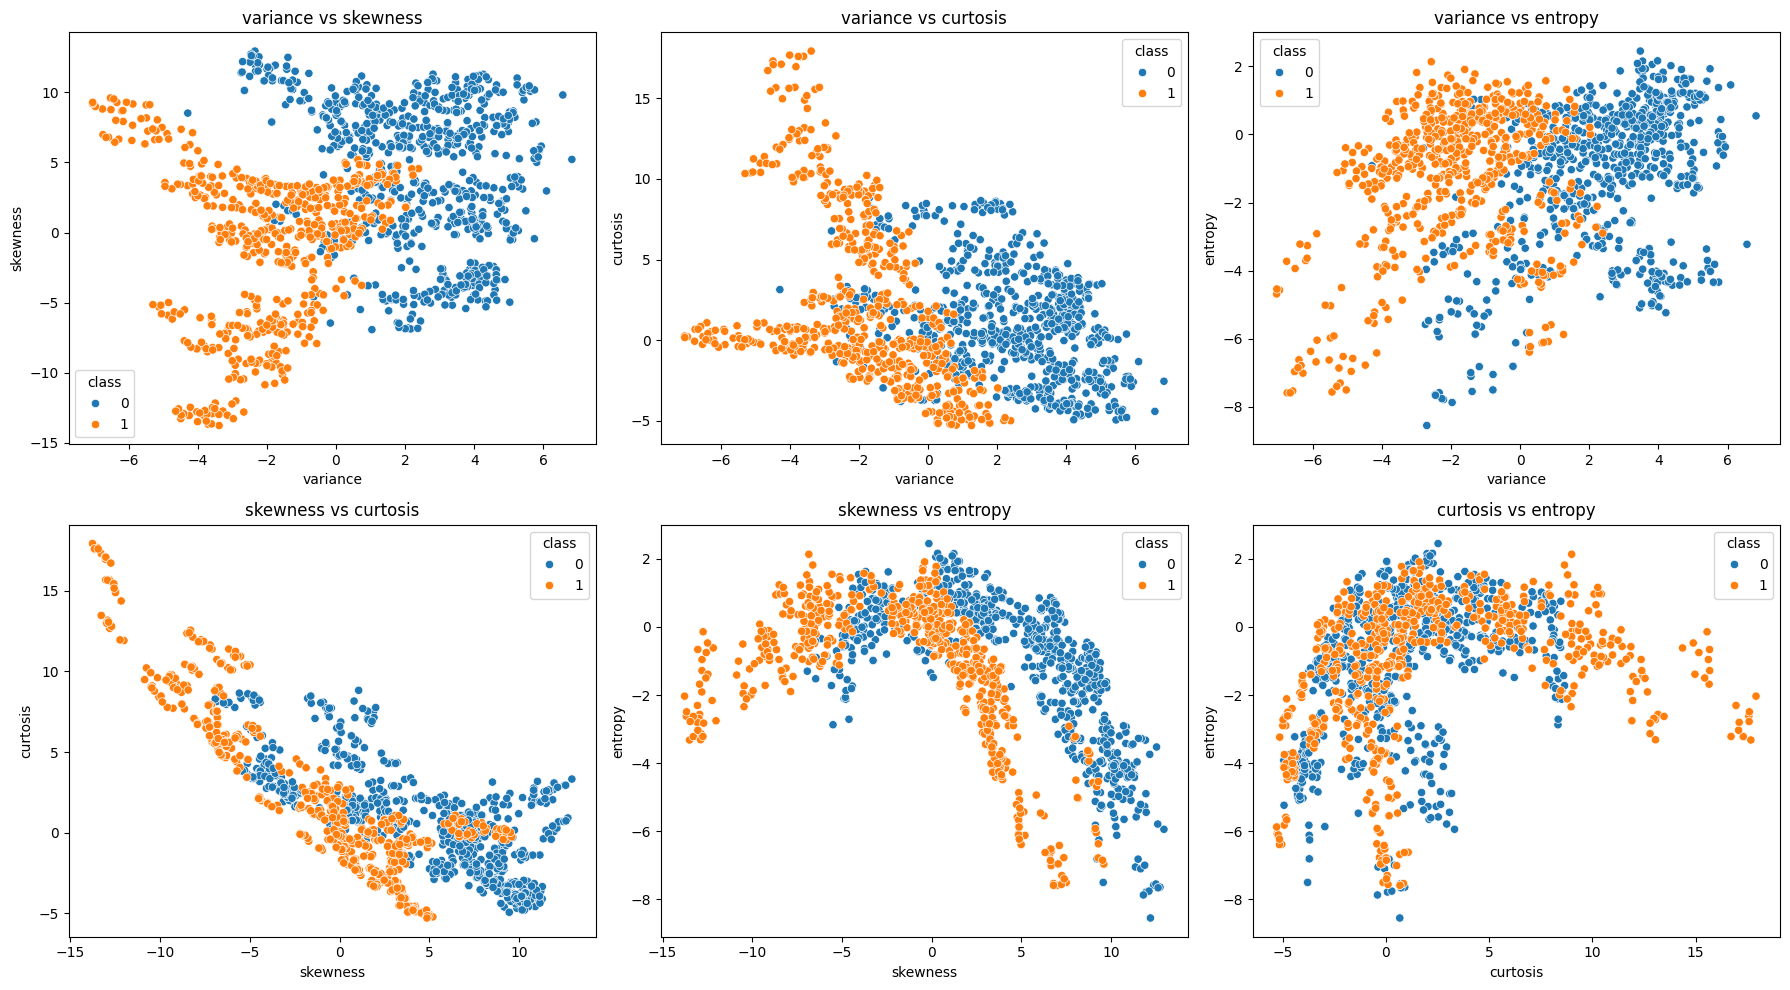

In [61]:

features = ["variance", "skewness", "curtosis", "entropy"]
pairs = list(combinations(features, 2))

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for ax, (x_feature, y_feature) in zip(axes.flat, pairs):

    sns.scatterplot(
        data=df,
        x=x_feature,
        y=y_feature,
        hue="class",
        ax=ax
    )

    ax.set_title(f"{x_feature} vs {y_feature}")

plt.tight_layout()
plt.show()

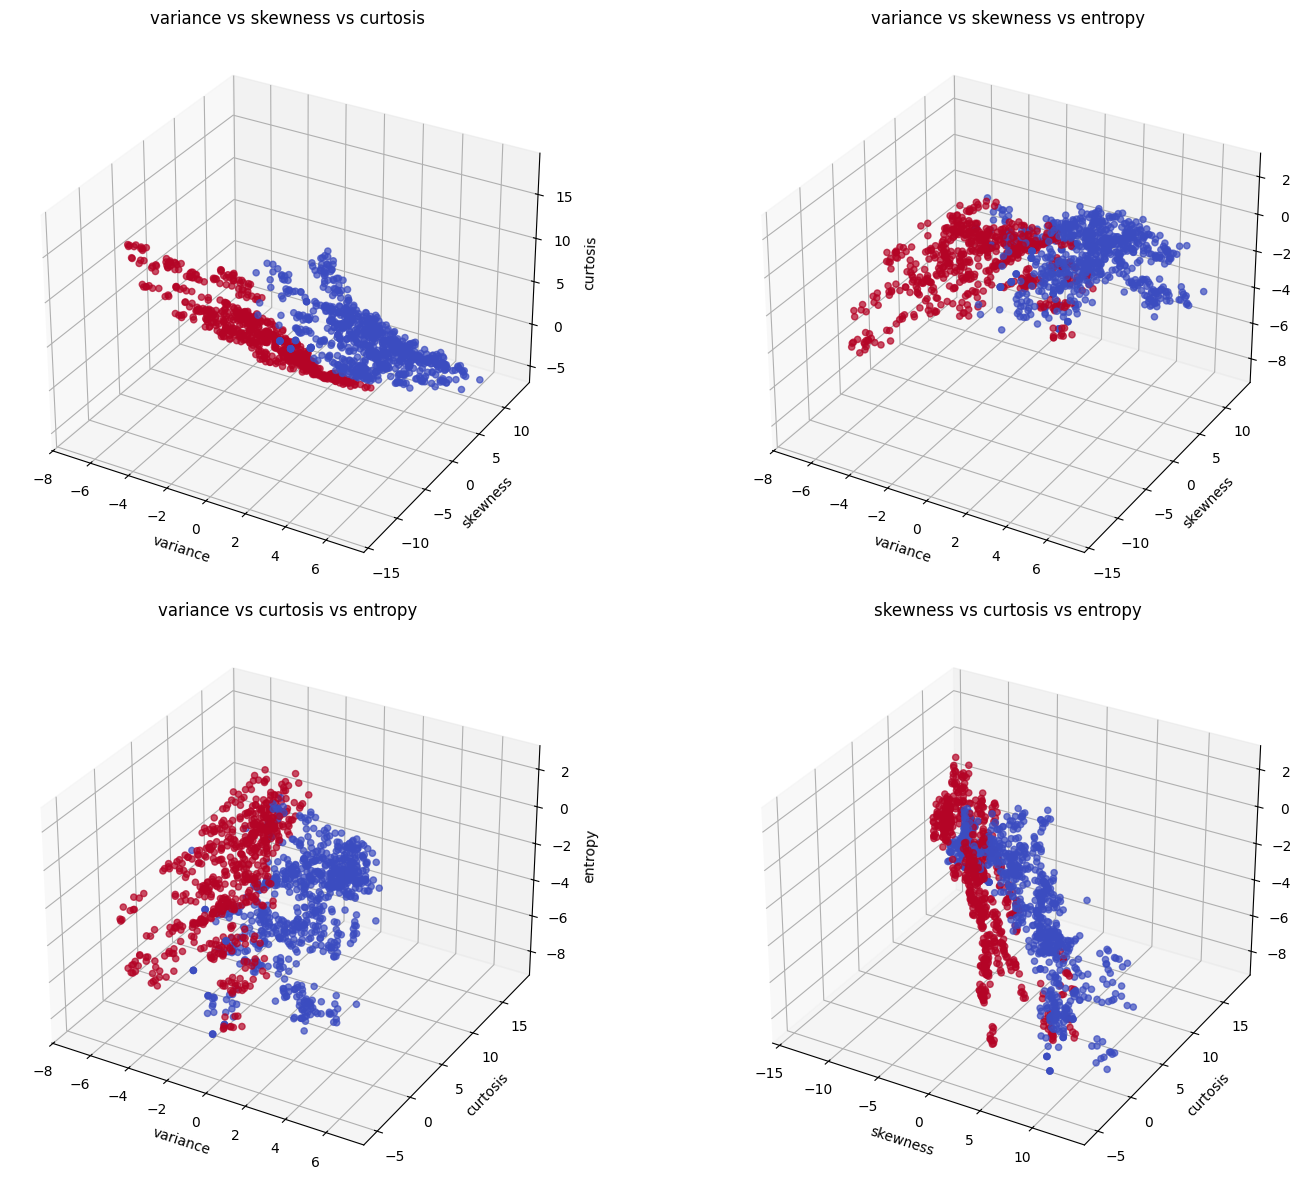

In [62]:
features = ["variance", "skewness", "curtosis", "entropy"]
triplets = list(combinations(features, 3))

fig = plt.figure(figsize=(16, 12))

for i, (x_feature, y_feature, z_feature) in enumerate(triplets, 1):

    ax = fig.add_subplot(2, 2, i, projection="3d")

    scatter = ax.scatter(
        df[x_feature],
        df[y_feature],
        df[z_feature],
        c=df["class"],
        cmap="coolwarm",
        alpha=0.7
    )

    ax.set_xlabel(x_feature)
    ax.set_ylabel(y_feature)
    ax.set_zlabel(z_feature)
    ax.set_title(f"{x_feature} vs {y_feature} vs {z_feature}")

plt.tight_layout()
plt.show()

# 5 Define the metric  
sicne the knn is to  classify based on the vote of the k nearset so we need metric notion and the most intutive is the  euclidean and as most of u  has done the prepa so for  sure u do know more so for that i need u to play with so 
# What to implent
impelent distance(X1,X2,metic:str="euclidean",**metric_params)


In [89]:
def distance(
    X1: np.ndarray,
    X2: np.ndarray,
    metric: str = "euclidean",
    **metric_params
) -> np.ndarray:

    # X1: (n_samples_1, n_features)
    # X2: (n_samples_2, n_features)

    diff = X1[:, np.newaxis, :] - X2[np.newaxis, :, :]
    #       (n1, 1, f)          (1, n2, f)
    #              ↓ broadcasting
    #              (n1, n2, f)

    if metric == "euclidean":
        return np.sqrt(np.sum(diff ** 2, axis=2))

    elif metric == "minkowski":
        p = metric_params.get("p", 2)
        return np.sum(np.abs(diff) ** p, axis=2) ** (1 / p)

    elif metric == "chebyshev":
        return np.max(np.abs(diff), axis=2)

    else:
        raise ValueError(
            f"Unknown metric {metric}. "
            "Choose from ['euclidean', 'minkowski', 'tchybechev']"
        )

In [64]:
x1 = np.random.randn(1,12,4)
x2 = np.random.randn(1,4)
dis = distance(x1,x2,metric="tchybechev",p=2)
dis

array([[[2.85989253, 1.86051492, 2.06318485, 2.45333791]]])

# Building Resuable KNN Estimator

In [65]:
class KNNClassifier:

    def __init__(
        self,
        k: int = 5,
        metric: str = "euclidean",
        weights: str = "uniform",
        **metric_params
    ):
        if weights not in ("uniform", "distance"):
            raise ValueError(
                f"Unknown weights '{weights}'. "
                "Choose from ['uniform', 'distance']"
            )

        self.k = k
        self.metric = metric
        self.metric_params = metric_params
        self.weights = weights

        self.X_ = None
        self.y_ = None

    def fit(self, X, y):
        self.X_ = np.asarray(X)
        self.y_ = np.asarray(y)

        return self

    def _distance(self, X1, X2):
        return distance(
            X1,
            X2,
            metric=self.metric,
            **self.metric_params
        )

    def _get_neighbors(self, distances):
        return np.argsort(distances, axis=1)[:, :self.k]

    def _majority_vote(self, neighbor_indices):
        return self.y_[neighbor_indices]

    def predict(self, X):

        X = np.asarray(X)

        distances = self._distance(X, self.X_)

        neighbor_indices = self._get_neighbors(distances)

        neighbor_classes = self.y_[neighbor_indices]

        # Uniform voting
        if self.weights == "uniform":

            predictions = np.array([
                np.bincount(classes).argmax()
                for classes in neighbor_classes
            ])

            return predictions

        # Distance-weighted voting
        elif self.weights == "distance":

            neighbor_distances = np.take_along_axis(
                distances,
                neighbor_indices,
                axis=1
            )

            weights = 1 / (neighbor_distances + 1e-6)

            n_classes = np.max(self.y_) + 1

            scores = np.zeros(
                (X.shape[0], n_classes)
            )

            for c in range(n_classes):
                scores[:, c] = np.sum(
                    weights * (neighbor_classes == c),
                    axis=1
                )

            predictions = np.argmax(scores, axis=1)

            return predictions
    def __call__(self, X:np.ndarray)->np.ndarray:
        return self.predict(X)


# 14. First real experiment

In [66]:
knn = KNNClassifier(k=5)
knn.fit(X_train,y_train)
y_pred = knn(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       153
           1       1.00      1.00      1.00       122

    accuracy                           1.00       275
   macro avg       1.00      1.00      1.00       275
weighted avg       1.00      1.00      1.00       275



# Classication report  and confusion matrix

In [67]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       153
           1       1.00      1.00      1.00       122

    accuracy                           1.00       275
   macro avg       1.00      1.00      1.00       275
weighted avg       1.00      1.00      1.00       275



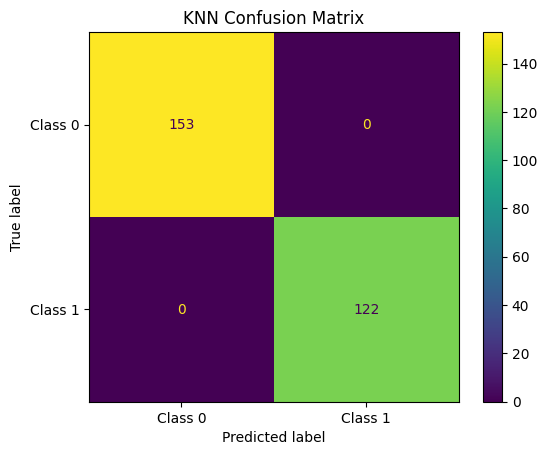

In [68]:
cm = confusion_matrix(y_test,y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=["Class 0","Class 1"])

disp.plot()
plt.title("KNN Confusion Matrix")
plt.show()

# Understanding k
This experiment is  for understanding the effect of k .We are not using the test set too choose the final model

In [78]:
k_values = [1, 3, 5, 7, 11, 15,17,21]
accuracies = []

for k in k_values:
    knn = KNNClassifier(k=k)
    knn.fit(X_train,y_train)
    y_pred = knn(X_test)
    acc = accuracy_score(y_test,y_pred)*100
    accuracies.append(acc)
accuracies

    

[100.0,
 100.0,
 100.0,
 100.0,
 100.0,
 99.63636363636364,
 98.9090909090909,
 98.9090909090909]

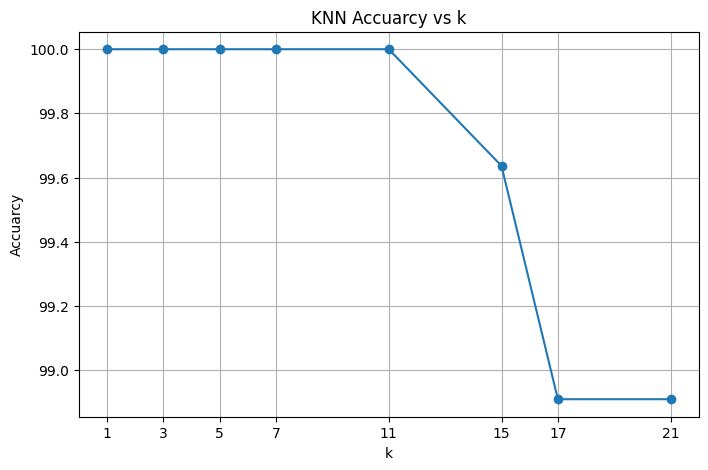

In [70]:
plt.figure(figsize=(8,5))
plt.plot(k_values,accuracies,marker="o")

plt.xlabel("k")
plt.ylabel("Accuarcy")
plt.title("KNN Accuarcy vs k")
plt.xticks(list(k_values))
plt.grid(True)

plt.show()

# Scaling experiment
And this is where Banknote Authentification is  useful  becauseits numerical features have different distribution/scales
we  will demonstrate 
KNN
without scaling
        ↓
distances
        ↓
some features can dominate
And as usual we dont fit the scaler on X_test : Put in Mind dont forget

In [71]:
scaler = StandardScaler()
X_train_scaled= scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)


In [83]:
accuracies_scaler = []
for k in k_values:
    knn_ = KNNClassifier(k=k)
    knn_.fit(X_train_scaled,y_train)
    y_pred = knn_(X_test_scaled)
    acc = accuracy_score(y_test,y_pred)*100
    accuracies_scaler.append(acc)
accuracies_scaler

[100.0,
 100.0,
 100.0,
 100.0,
 100.0,
 99.63636363636364,
 98.9090909090909,
 98.9090909090909]

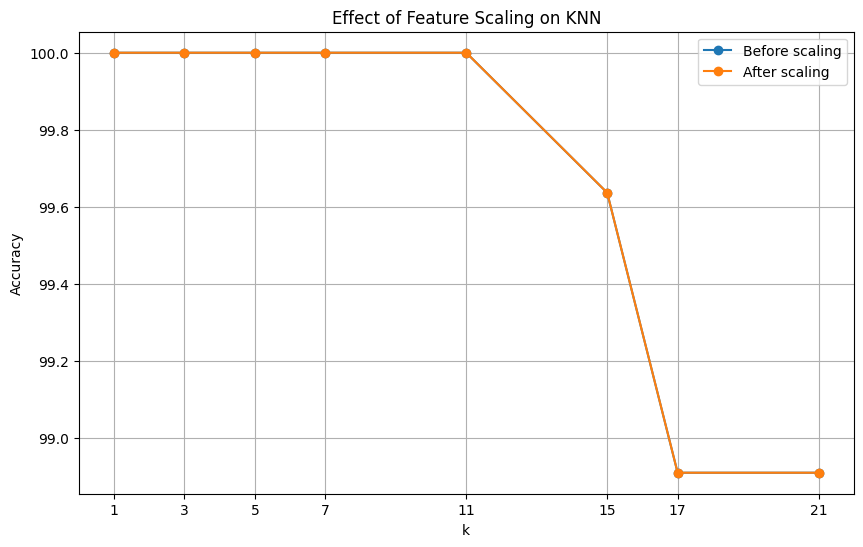

In [84]:
plt.figure(figsize=(10, 6))

plt.plot(
    k_values,
    accuracies,
    marker="o",
    label="Before scaling"
)

plt.plot(
    k_values,
    accuracies_scaler,
    marker="o",
    label="After scaling"
)

plt.xlabel("k")
plt.ylabel("Accuracy")
plt.title("Effect of Feature Scaling on KNN")
plt.xticks(k_values)
plt.legend()
plt.grid(True)

plt.show()

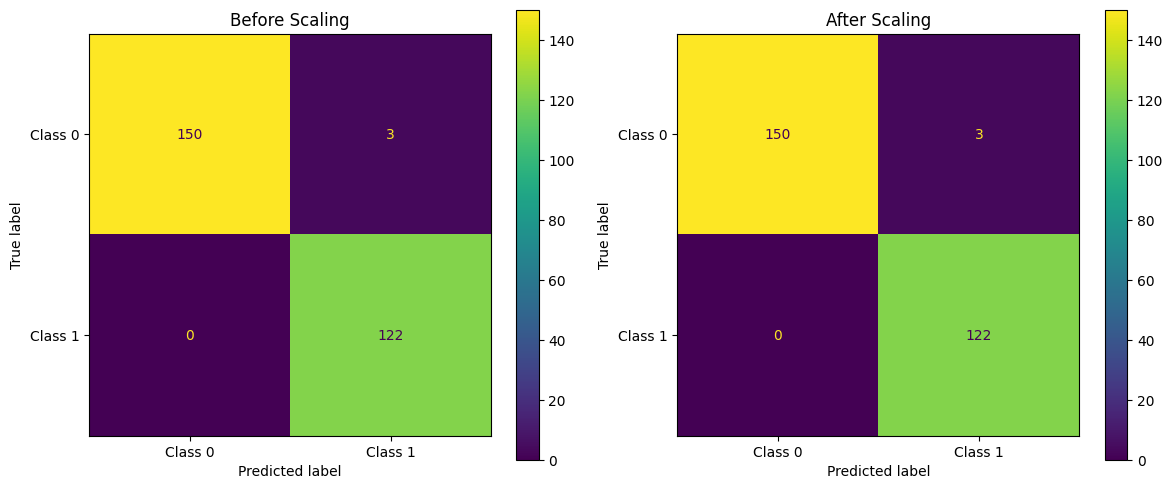

In [82]:
knn_before = KNNClassifier(k =17)
knn_before.fit(X_train,y_train)
y_pred = knn_before(X_test)

knn_scaled = KNNClassifier(k=17)
knn_scaled.fit(X_train_scaled,y_train)
y_pred_scaled = knn_scaled(X_test_scaled)

cm_before = confusion_matrix(y_test, y_pred)
cm_scaled = confusion_matrix(y_test, y_pred_scaled)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay(
    cm_before,
    display_labels=["Class 0", "Class 1"]
).plot(ax=axes[0])

axes[0].set_title("Before Scaling")

ConfusionMatrixDisplay(
    cm_scaled,
    display_labels=["Class 0", "Class 1"]
).plot(ax=axes[1])

axes[1].set_title("After Scaling")

plt.tight_layout()
plt.show()

# Experiment  the different metric , different weights and k

In [95]:
metrics = ["euclidean", "minkowski", "chebyshev"]
weights = ["uniform", "distance"]

results = {}

for metric in metrics:

    for weight in weights:

        key = f"{metric}_{weight}"
        results[key] = []

        for k in k_values:

            if metric == "minkowski":
                knn = KNNClassifier(
                    k=k,
                    metric=metric,
                    weights=weight,
                    p=3
                )
            else:
                knn = KNNClassifier(
                    k=k,
                    metric=metric,
                    weights=weight
                )

            knn.fit(X_train_scaled, y_train)

            y_pred = knn(X_test_scaled)

            accuracy = np.mean(y_pred == y_test)

            results[key].append(accuracy)

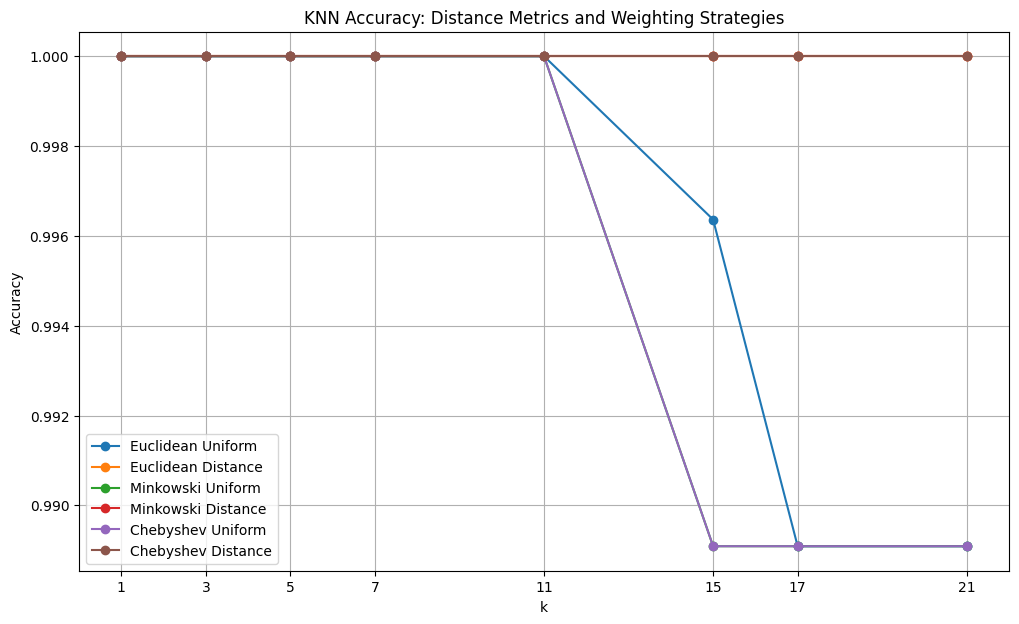

In [96]:
plt.figure(figsize=(12, 7))

for key, accuracies_metric in results.items():

    plt.plot(
        k_values,
        accuracies_metric,
        marker="o",
        label=key.replace("_", " ").title()
    )

plt.xlabel("k")
plt.ylabel("Accuracy")
plt.title("KNN Accuracy: Distance Metrics and Weighting Strategies")
plt.xticks(k_values)
plt.legend()
plt.grid(True)

plt.show()

# 18. Final reflection

We finish with conceptual questions rather than another coding exercise.

For example:

Question 1

Why is KNN called a lazy learner?

Question 2

Why does fit() look very different from SVM or Logistic Regression?

Question 3

Why does feature scaling matter for KNN?

Question 4

What happens when k is too small?

Question 5

What happens when k is too large?

Question 6

What is one advantage and one disadvantage of KNN compared with SVM?